In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# データを読み込み、すべての列を数値型に変換
data = pd.read_csv("Pb_labeled.csv")
data.columns = data.columns.str.strip()  # 列名の空白を削除

a=len(data)
print(a)
# すべての列を数値型に変換し、無効な値をNaNに置き換え
data = data.apply(pd.to_numeric, errors='coerce')

# NaNを含む行を削除
data_cleaned = data.dropna()

2239602


In [2]:
GRtiming=data_cleaned['GRQ2timing']
LAStiming=data_cleaned['LASQ1timing']
TDiff=LAStiming-GRtiming

xdp=data_cleaned['GRX']
adp=data_cleaned['GRA']
ydp=data_cleaned['GRY']
bdp=data_cleaned['GRB']
GRQ2=data_cleaned['GRQ2charge']

correct=data_cleaned[
    (TDiff != 0) & (xdp!=-9999) & (ydp!=-9999)
]

GRtiming=correct['GRQ2timing']
LAStiming=correct['LASQ1timing']
TDiff=LAStiming-GRtiming

Text(0, 0.5, 'counts')

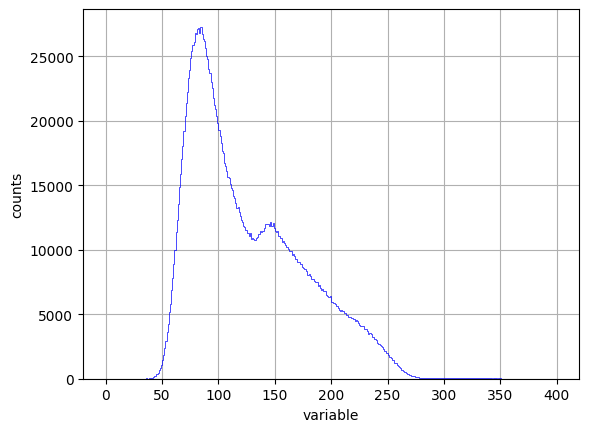

In [3]:
TOT=correct['LASTOT']
Lx=correct['LASX']
GRtiming=correct['GRQ2timing']
LAStiming=correct['LASQ1timing']
TDiff=LAStiming-GRtiming

import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
variable=TOT
#hist range
range_min=0
range_max=400
#bin width
x_bin_width=1
####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅を10に設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('variable')
ax.set_ylabel('counts')

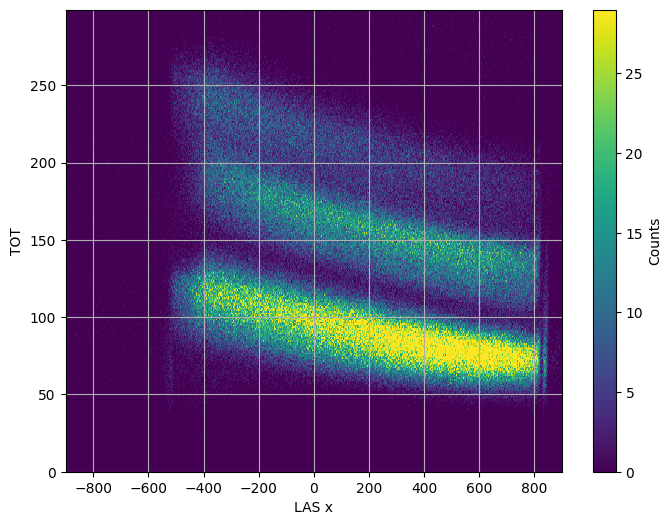

In [27]:
from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
x_axis_variable=Lx
y_axis_variable=TOT
#hist range
x_axis_range_min=-900
x_axis_range_max=900
y_axis_range_min=0
y_axis_range_max=300
#bin width
x_bin_width=1
y_bin_width=1
######################################################

# ヒストグラムを作成
bins = [np.arange(x_axis_range_min, x_axis_range_max, x_bin_width),
        np.arange(y_axis_range_min, y_axis_range_max, y_bin_width)]
hist, xedges, yedges = np.histogram2d(x_axis_variable, y_axis_variable, bins=bins)

# 図の準備
fig, ax = plt.subplots(figsize=(8, 6))
# ヒートマップの作成（カウントに応じて色付け）
norm = Normalize(vmin=0, vmax=np.max(hist) // 2)  # 色の範囲を細かく調整
mesh = ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto', norm=norm)

# カラーバーを追加
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Counts')

# 軸範囲とグリッド
ax.set_xlabel('LAS x')
ax.set_ylabel('TOT')
ax.grid()

plt.show()

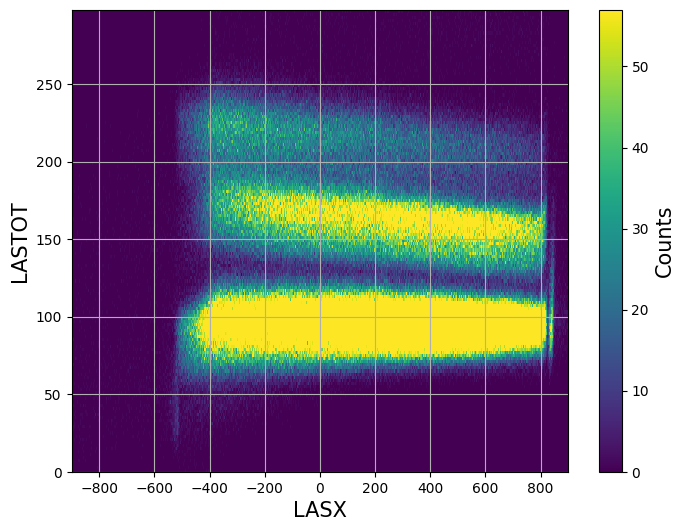

In [18]:
TOTc=TOT+0.0430496*Lx-2.0e-5*(Lx**2)

from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
x_axis_variable=Lx
y_axis_variable=TOTc
#hist range
x_axis_range_min=-900
x_axis_range_max=900
y_axis_range_min=0
y_axis_range_max=300
#bin width
x_bin_width=2
y_bin_width=2
######################################################

# ヒストグラムを作成
bins = [np.arange(x_axis_range_min, x_axis_range_max, x_bin_width),
        np.arange(y_axis_range_min, y_axis_range_max, y_bin_width)]
hist, xedges, yedges = np.histogram2d(x_axis_variable, y_axis_variable, bins=bins)

# 図の準備
fig, ax = plt.subplots(figsize=(8, 6))
# ヒートマップの作成（カウントに応じて色付け）
norm = Normalize(vmin=0, vmax=np.max(hist) // 3)  # 色の範囲を細かく調整
mesh = ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto', norm=norm)

# カラーバーを追加
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Counts', fontsize=15)

# 軸範囲とグリッド
ax.set_xlabel('LASX', fontsize=15)
ax.set_ylabel('LASTOT', fontsize=15)
ax.grid()

plt.show()

Text(0, 0.5, 'counts')

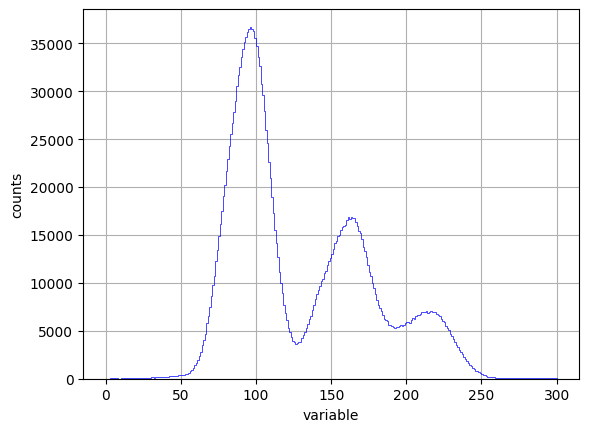

In [20]:
import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
variable=TOTc
#hist range
range_min=0
range_max=300
#bin width
x_bin_width=1
####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅を10に設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('variable')
ax.set_ylabel('counts')

In [21]:
# アルファゲートを設定
alpha_gated=correct[
    (TOT+0.0430496*Lx-1.3842e-5*(Lx**2)>190) & (TOT+0.0430496*Lx-1.3842e-5*(Lx**2)<250)
]
# alpha_gated=correct[
#     (TOT+0.0430496*Lx-1.3842e-5*(Lx**2)>190) & (TOT+0.0430496*Lx-1.3842e-5*(Lx**2)<250)
# ]

TOT_alpha=alpha_gated['LASTOT']
Lx_alpha=alpha_gated['LASX']
GRtiming_alpha=alpha_gated['GRQ2timing']
LAStiming_alpha=alpha_gated['LASQ1timing']
TDiff_alpha=LAStiming_alpha-GRtiming_alpha

Text(0, 0.5, 'counts')

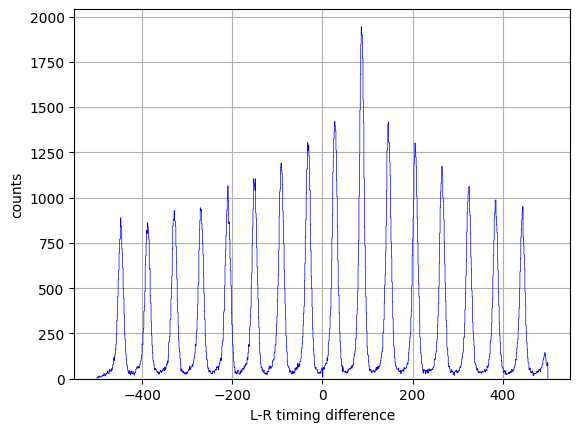

In [22]:
import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
variable=TDiff_alpha
#hist range
range_min=-500
range_max=500
#bin width
x_bin_width=1
####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅を10に設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('L-R timing difference')
ax.set_ylabel('counts')